# Baseline V2 — classification logistique sparse

Ce notebook présente le modèle final, sa validation par dates entières, sa
stabilité et les variables qui contribuent le plus. La V2 n'utilise **ni ordre
des dates**, **ni target encoding**, **ni reconstruction des fenêtres**.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
V1 = ROOT / "gpt" / "outputs" / "v1_recheck"
V2 = ROOT / "gpt" / "outputs" / "v2"
OOF_V2 = ROOT / "gpt" / "outputs" / "classification_full" / "oof_logistic_C_0.003.csv"
print(f"Racine du projet: {ROOT}")

Racine du projet: /Users/macbookpro/Desktop/Machine_Learning/challenge_data_ens/data_challenge_qrt


## 1. Résultat principal

La V1 prédit un rendement continu avec une Ridge. La V2 prédit directement la
probabilité d'un signe positif avec une logistique L2.

In [2]:
with (V1 / "cv_summary.json").open() as f:
    v1_summary = json.load(f)
with (V2 / "summary.json").open() as f:
    v2_summary = json.load(f)

comparison = pd.DataFrame([
    {
        "modèle": "V1 Ridge",
        "accuracy": v1_summary["scores"]["ts"]["accuracy"],
        "erreur standard TS": v1_summary["scores"]["ts"]["standard_error"],
        "score pénalisé TS": v1_summary["scores"]["ts"]["score"],
    },
    {
        "modèle": "V2 Logistique",
        "accuracy": v2_summary["cv"]["accuracy"],
        "erreur standard TS": v2_summary["cv"]["ts_standard_error"],
        "score pénalisé TS": v2_summary["cv"]["ts_penalized_score"],
    },
])
comparison

,modèle,accuracy,erreur standard TS,score pénalisé TS
0,V1 Ridge,0.524709,0.001734,0.522975
1,V2 Logistique,0.525001,0.001716,0.523285


## 2. Validation

Les 2 522 valeurs de `TS` sont réparties dans huit folds. Toutes les allocations
d'une date restent ensemble. Le numéro contenu dans `DATE_xxxx` n'est jamais
utilisé comme information temporelle.

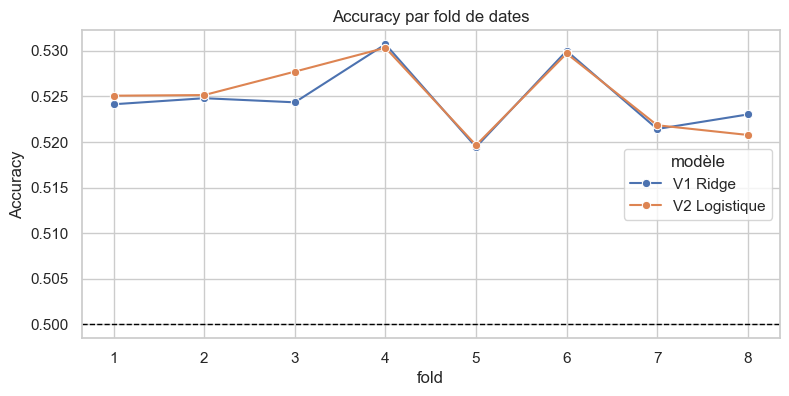

modèle,V1 Ridge,V2 Logistique
fold,,
1.0,0.524137,0.525077
2.0,0.524801,0.525147
3.0,0.524349,0.527720
4.0,0.530721,0.530334
5.0,0.519440,0.519648
6.0,0.529994,0.529708
7.0,0.521425,0.521832
8.0,0.523019,0.520769


In [3]:
v1_folds = pd.read_csv(V1 / "fold_metrics.csv")[["fold", "accuracy"]].assign(modèle="V1 Ridge")
v2_folds = pd.read_csv(V2 / "fold_metrics.csv")[["fold", "accuracy"]].assign(modèle="V2 Logistique")
folds = pd.concat([v1_folds, v2_folds], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=folds, x="fold", y="accuracy", hue="modèle", marker="o", ax=ax)
ax.axhline(0.5, color="black", lw=1, ls="--")
ax.set_title("Accuracy par fold de dates")
ax.set_ylabel("Accuracy")
plt.show()
folds.pivot(index="fold", columns="modèle", values="accuracy")

## 3. Stabilité par date et allocation

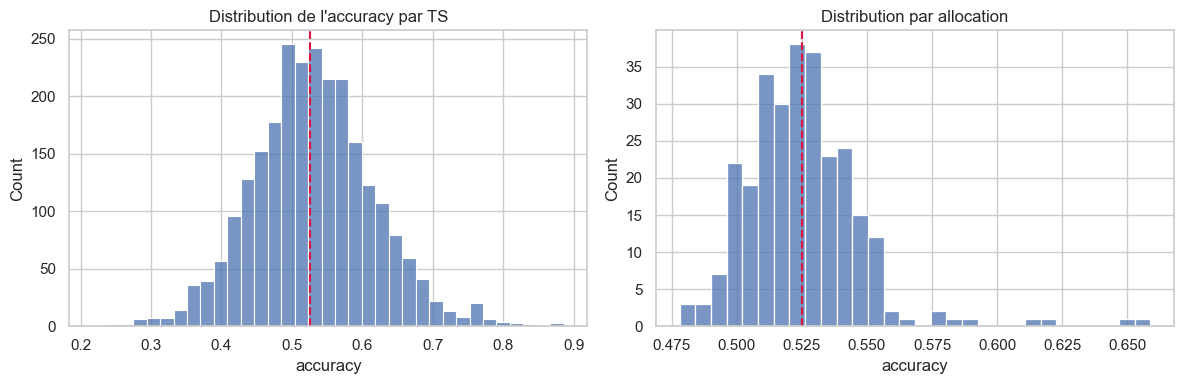

,niveau,nombre,accuracy moyenne non pondérée,écart-type
0,TS,2522,0.530185,0.086171
1,ALLOCATION,278,0.525110,0.022551


In [4]:
oof = pd.read_csv(OOF_V2, index_col="ROW_ID")
stability_ts = oof.groupby("TS")["is_correct"].agg(["size", "mean"]).rename(columns={"size": "n", "mean": "accuracy"})
stability_allocation = oof.groupby("ALLOCATION")["is_correct"].agg(["size", "mean"]).rename(columns={"size": "n", "mean": "accuracy"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(stability_ts["accuracy"], bins=35, ax=axes[0])
axes[0].axvline(v2_summary["cv"]["accuracy"], color="crimson", ls="--")
axes[0].set_title("Distribution de l'accuracy par TS")
sns.histplot(stability_allocation["accuracy"], bins=30, ax=axes[1])
axes[1].axvline(v2_summary["cv"]["accuracy"], color="crimson", ls="--")
axes[1].set_title("Distribution par allocation")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "niveau": ["TS", "ALLOCATION"],
    "nombre": [len(stability_ts), len(stability_allocation)],
    "accuracy moyenne non pondérée": [stability_ts.accuracy.mean(), stability_allocation.accuracy.mean()],
    "écart-type": [stability_ts.accuracy.std(), stability_allocation.accuracy.std()],
})

## 4. Importance des variables

L'importance est mesurée par l'écart-type de la contribution
`coefficient × feature`, ce qui est plus lisible qu'un coefficient brut pour
comparer variables continues et one-hot.

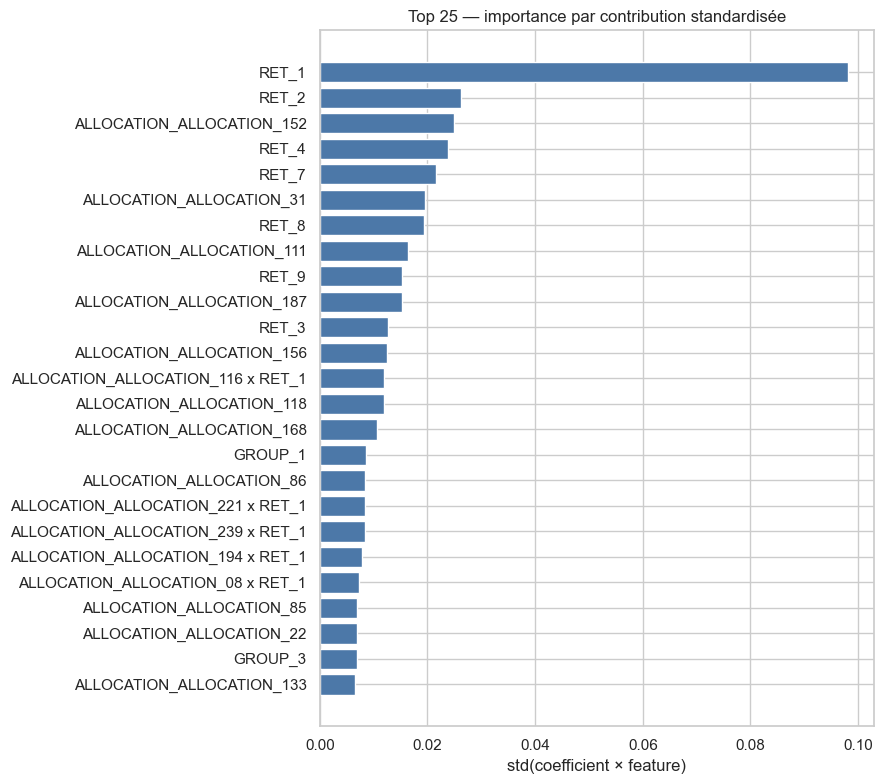

,feature,coefficient,feature_std,contribution_std
0,RET_1,0.098047,1.000000,0.098047
1,RET_2,-0.026252,1.000000,0.026252
2,ALLOCATION_ALLOCATION_152,0.366841,0.067868,0.024897
3,RET_4,-0.023842,1.000000,0.023842
4,RET_7,0.021533,1.000000,0.021533
5,ALLOCATION_ALLOCATION_31,0.327981,0.059363,0.019470
6,RET_8,0.019432,1.000000,0.019432
7,ALLOCATION_ALLOCATION_111,-0.274405,0.059363,0.016290
8,RET_9,0.015303,1.000000,0.015303
9,ALLOCATION_ALLOCATION_187,0.252106,0.060417,0.015231


In [5]:
importance = pd.read_csv(V2 / "feature_importance.csv")
top = importance.head(25).sort_values("contribution_std")
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top["feature"], top["contribution_std"], color="#4C78A8")
ax.set_title("Top 25 — importance par contribution standardisée")
ax.set_xlabel("std(coefficient × feature)")
plt.tight_layout()
plt.show()
importance.head(15)

## 5. Vérification de la soumission

In [6]:
submission = pd.read_csv(V2 / "submission.csv", index_col="ROW_ID")
checks = pd.Series({
    "nombre de lignes": len(submission),
    "valeurs manquantes": int(submission.isna().sum().sum()),
    "classes": sorted(submission.iloc[:, 0].unique().tolist()),
    "taux positif": submission.iloc[:, 0].mean(),
})
display(checks)
submission.head()

nombre de lignes         31870
valeurs manquantes           0
classes                 [0, 1]
taux positif          0.602259
dtype: object

,prediction
ROW_ID,
527073,1
527074,1
527075,0
527076,1
527077,0


## 6. Formule et reproduction

La formulation complète est dans `gpt/model_v2_math.md`. Pour régénérer la
soumission depuis la racine du projet :

```bash
python gpt/model_v2.py
```

Le journal détaillé des expériences acceptées et rejetées se trouve dans
`gpt/RESEARCH_LOG.md`.